In [1]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

In [2]:
#in_fn = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/gen_data/scdesign2_screadsim/simu/matrix/HCC3N_simu.gene.countmatrix.scDesign2Simulated.cna.h5ad'
#feature_label = 'super-gene'    # 'super-gene' or 'inter-gene'

in_fn = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/gen_data/scdesign2_screadsim/simu/matrix/HCC3N_simu.intergene.countmatrix.scDesign2Simulated.cna.h5ad'
feature_label = 'inter-gene'    # 'super-gene' or 'inter-gene'

out_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/gen_data/scdesign2_screadsim/analysis/cna_signals/'

In [3]:
adata = ad.read_h5ad(in_fn)
adata

/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 1200 × 21215
    obs: 'cell_type'
    var: 'gene', 'chrom', 'start', 'end', 'region', 'cn0', 'cn1', 'cna_type'

In [4]:
adata.var['cna_type'].value_counts()

cna_type
gain    1609
loss    1005
loh      798
Name: count, dtype: int64

## Copy gain signals

In [5]:
adata[adata.obs['cell_type'] == 'tumor', adata.var['cna_type'] == 'gain']

View of AnnData object with n_obs × n_vars = 600 × 1609
    obs: 'cell_type'
    var: 'gene', 'chrom', 'start', 'end', 'region', 'cn0', 'cn1', 'cna_type'

In [6]:
tmp = adata[adata.obs['cell_type'] == 'tumor', adata.var['cna_type'] == 'gain'].copy()
X_tumor = tmp.X
print(X_tumor.shape)

tmp = adata[adata.obs['cell_type'] == 'normal', adata.var['cna_type'] == 'gain'].copy()
X_normal = tmp.X
print(X_normal.shape)

(600, 1609)
(600, 1609)


In [7]:
fc = np.log2( ( X_tumor.mean(axis = 0)*1e6 ) / ( X_normal.mean(axis = 0)*1e6 + 1e-8 ) )
RD = np.log10(X_normal.mean(axis = 0) + 1)

/tmp/pbs.1794309.xomics/ipykernel_23691/2984778493.py:1: RuntimeWarning: divide by zero encountered in log2
  fc = np.log2( ( X_tumor.mean(axis = 0)*1e6 ) / ( X_normal.mean(axis = 0)*1e6 + 1e-8 ) )


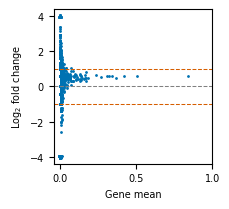

In [8]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (2.4, 2.2))

cut = (-4, 4)
cut_markers = ('v', '^')
fontsize = 7
def_color = '#0072B2'
red = '#D55E00'     # Vermillion

vx = RD
vy = fc

low, high = cut
x1 = vx[vy > high]
y1 = np.repeat(high, len(x1))
x2 = vx[np.logical_and(vy >= low, vy <= high)]
y2 = vy[np.logical_and(vy >= low, vy <= high)]
x3 = vx[vy < low]
y3 = np.repeat(low, len(x3))
    
ax.plot(x1, y1, marker = cut_markers[1], markersize = 2, 
        linestyle = 'none', color = def_color)
ax.plot(x2, y2, marker = '.', markersize = 2, 
        linestyle = 'none', color = def_color)
ax.plot(x3, y3, marker = cut_markers[0], markersize = 2, 
        linestyle = 'none', color = def_color)

fc_kws = dict()
ax.axhline(
    y = fc_kws.get('y_up', 1),
    linestyle = fc_kws.get('linestyle', '--'),
    linewidth = fc_kws.get('linewidth', 0.75),
    color = fc_kws.get('color', red)
)
ax.axhline(
    y = fc_kws.get('y_low', -1),
    linestyle = fc_kws.get('linestyle', '--'),
    linewidth = fc_kws.get('linewidth', 0.75),
    color = fc_kws.get('color', red)
)

ref_kws = dict()
ax.axhline(
    y = ref_kws.get('y', 0), 
    linestyle = ref_kws.get('linestyle', '--'), 
    linewidth = ref_kws.get('linewidth', 0.75),
    color = ref_kws.get('color', 'gray')
)
#ax.set_xticks([0, 1, 2])    # for super-gene
ax.set_xticks([0, 0.5, 1])
ax.set_xticklabels(
    ax.get_xticklabels(), 
    fontsize = fontsize
)
ax.set_ylim(-4.4, 4.4)
ax.set_yticks([-4, -2, 0, 2, 4])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = fontsize
)
ax.set_xlabel("Gene mean", fontsize = fontsize)
ax.set_ylabel(r"Log$_2$ fold change", fontsize = fontsize)

for s in ["top", "right"]:
    ax.spines[s].set_visible(True)
        
plt.tight_layout()
fn = os.path.join(out_dir, "%s-gain-log2fc-vs-mean.png" % feature_label)
fig.savefig(fn, dpi = 300)

## Copy loss signals

In [9]:
adata[adata.obs['cell_type'] == 'tumor', adata.var['cna_type'] == 'loss']

View of AnnData object with n_obs × n_vars = 600 × 1005
    obs: 'cell_type'
    var: 'gene', 'chrom', 'start', 'end', 'region', 'cn0', 'cn1', 'cna_type'

In [10]:
tmp = adata[adata.obs['cell_type'] == 'tumor', adata.var['cna_type'] == 'loss'].copy()
X_tumor = tmp.X
print(X_tumor.shape)

tmp = adata[adata.obs['cell_type'] == 'normal', adata.var['cna_type'] == 'loss'].copy()
X_normal = tmp.X
print(X_normal.shape)

(600, 1005)
(600, 1005)


In [11]:
fc = np.log2( ( X_tumor.mean(axis = 0)*1e6 ) / ( X_normal.mean(axis = 0)*1e6 + 1e-8 ) )
RD = np.log10(X_normal.mean(axis = 0) + 1)

/tmp/pbs.1794309.xomics/ipykernel_23691/2984778493.py:1: RuntimeWarning: divide by zero encountered in log2
  fc = np.log2( ( X_tumor.mean(axis = 0)*1e6 ) / ( X_normal.mean(axis = 0)*1e6 + 1e-8 ) )


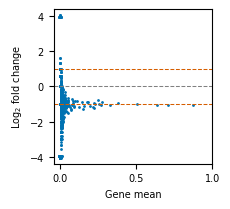

In [12]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (2.4, 2.2))

cut = (-4, 4)
cut_markers = ('v', '^')
fontsize = 7
def_color = '#0072B2'
red = '#D55E00'     # Vermillion

vx = RD
vy = fc

low, high = cut
x1 = vx[vy > high]
y1 = np.repeat(high, len(x1))
x2 = vx[np.logical_and(vy >= low, vy <= high)]
y2 = vy[np.logical_and(vy >= low, vy <= high)]
x3 = vx[vy < low]
y3 = np.repeat(low, len(x3))
    
ax.plot(x1, y1, marker = cut_markers[1], markersize = 2, 
        linestyle = 'none', color = def_color)
ax.plot(x2, y2, marker = '.', markersize = 2, 
        linestyle = 'none', color = def_color)
ax.plot(x3, y3, marker = cut_markers[0], markersize = 2, 
        linestyle = 'none', color = def_color)

fc_kws = dict()
ax.axhline(
    y = fc_kws.get('y_up', 1),
    linestyle = fc_kws.get('linestyle', '--'),
    linewidth = fc_kws.get('linewidth', 0.75),
    color = fc_kws.get('color', red)
)
ax.axhline(
    y = fc_kws.get('y_low', -1),
    linestyle = fc_kws.get('linestyle', '--'),
    linewidth = fc_kws.get('linewidth', 0.75),
    color = fc_kws.get('color', red)
)

ref_kws = dict()
ax.axhline(
    y = ref_kws.get('y', 0), 
    linestyle = ref_kws.get('linestyle', '--'), 
    linewidth = ref_kws.get('linewidth', 0.75),
    color = ref_kws.get('color', 'gray')
)
#ax.set_xticks([0, 1, 2, 3])   # for super-gene
ax.set_xticks([0, 0.5, 1])
ax.set_xticklabels(
    ax.get_xticklabels(), 
    fontsize = fontsize
)
ax.set_ylim(-4.4, 4.4)
ax.set_yticks([-4, -2, 0, 2, 4])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = fontsize
)
ax.set_xlabel("Gene mean", fontsize = fontsize)
ax.set_ylabel(r"Log$_2$ fold change", fontsize = fontsize)

for s in ["top", "right"]:
    ax.spines[s].set_visible(True)
        
plt.tight_layout()
fn = os.path.join(out_dir, "%s-loss-log2fc-vs-mean.png" % feature_label)
fig.savefig(fn, dpi = 300)